# Week 4 — Day 2: Cross-Validation
**BinX Tech AI & ML Internship — Phase 2**

**Dataset:** Telco Customer Churn  
**Task:** Binary Classification — will a customer leave? (Churn: Yes/No)





### Objective

**Evaluate model reliability with cross‑validation and measure churn detection performance using F1.**  
Replace a single train/validation split with **Stratified 5‑Fold Cross‑Validation** to obtain a more robust estimate of how well the Week 3 RandomForest model detects churn.

### Overview

- **Dataset:** Telco Customer Churn (preprocessed: `TotalCharges` cleaned, `customerID` dropped, `Churn` mapped to 0/1, categorical features one‑hot encoded).  
- **Why cross‑validation:** A single validation split can be unusually easy or hard; 5‑fold CV rotates the validation fold so every training row is validated once, reducing sampling noise and giving a more reliable performance estimate.  
- **Metric:** **F1 for the churn class** (positive class). F1 balances precision and recall and is preferred here because the dataset is imbalanced.  
- **Stratification:** Use `StratifiedKFold` so each fold preserves the churn/no‑churn ratio, ensuring fair evaluation of the minority class.

### What this notebook contains

- Per‑fold F1 scores and a bar chart showing fold variability.  
- Mean and standard deviation of CV F1 as the reliable performance estimate.  
- Direct comparison between Day 1 single‑split F1 and Day 2 CV mean, with an explanation of any discrepancy.  
- Verification that stratified folds preserved class balance and why that matters for churn prediction.

### Expected takeaway

Cross‑validation produces a **more honest, lower‑variance** estimate of real‑world performance than a single split; stratification is essential for fair evaluation on imbalanced classification tasks.


#### Imports

We need StratifiedKFold and cross_val_score on top of the Day 1 imports — these are the tools that let us run cross-validation instead of a single train/validation split.

In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report

#### Load & Clean the Data

* TotalCharges is stored as text — blank rows become NaN, filled with 0
* customerID is an identifier, not a feature — dropped
* Churn is Yes/No text — mapped to 1/0 for the model

In [57]:

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df = df.drop("customerID", axis=1)

# encode target 0: no churn, 1: churn
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
X = pd.get_dummies(df.drop("Churn", axis=1), drop_first=True)
y = df["Churn"]

# split the dataset 60% train, 20% validation, 20% test (same split as Day 1)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)


## Step 1: Take a Week 3 model and evaluate it with 5-fold cross-validation using cross_val_score.

A single validation split has a hidden weakness: if it happens to be an unusual slice of the data, the tuning decision it supports is based on luck, not signal. 5-fold cross-validation fixes this by rotating the validation role across 5 different folds of the training set and scoring each one, so no single split can dominate the result.

We use the same model from Day 1 (n_estimators=300) and score with F1, since accuracy is misleading on this imbalanced dataset. StratifiedKFold is used explicitly (rather than just passing cv=5) so that each fold preserves the churn/no-churn ratio.

In [58]:
model = RandomForestClassifier(n_estimators=300, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")

for i, score in enumerate(scores, 1):
    print(f"Fold {i} F1-Score: {score:.3f}")

Fold 1 F1-Score: 0.524
Fold 2 F1-Score: 0.531
Fold 3 F1-Score: 0.587
Fold 4 F1-Score: 0.528
Fold 5 F1-Score: 0.519


Each fold trained on 4/5 of X_train and validated on the remaining 1/5, so every row was used for validation exactly once. Fold 3 scored noticeably higher (0.587) than the rest — a reminder of exactly the kind of single-split luck cross-validation is meant to average out.

## Step 2: Report the mean and standard deviation of the scores across folds.

The mean is the reliable performance estimate; the standard deviation tells us how much that estimate would have wobbled if we'd only run one of the five folds.

In [59]:
mean = scores.mean()
std = scores.std()
print(f"\nMean CV F1-Score: {mean:.3f}")
print(f"Standard Deviation: {std:.3f}")



Mean CV F1-Score: 0.538
Standard Deviation: 0.025


A standard deviation of 0.025 (2.5 points) on a mean of 0.538 is fairly tight — the model's churn-detection performance doesn't swing wildly depending on which 20% of the training data was held out, so this mean is a trustworthy estimate rather than a fluke.

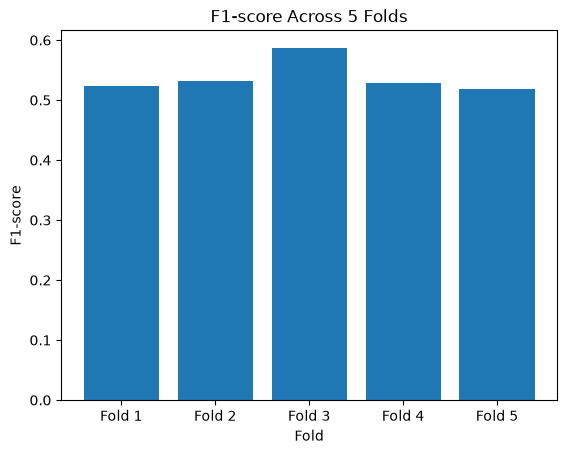

In [60]:
result = pd.DataFrame({
    "Fold": [f"Fold {i}" for i in range(1, len(scores) + 1)],
    "F1-score": scores
})

plt.bar(
    result["Fold"],
    result["F1-score"]
)

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("F1-score Across 5 Folds")
plt.show()

The bar chart shows each fold's F1 score side by side. Fold 3 stands out as the highest (0.587), while the rest cluster closer to 0.52–0.53 — visual confirmation that a single validation split (like Day 1's) can land on a fold that's easier or harder than average. Averaging across all 5 folds, rather than trusting any one bar, is what gives the more reliable Mean CV F1-Score reported in Step 2.

## Step 3: Compare the cross-validated estimate to the single-split score from Day 1 and explain any difference.

We refit the model on X_train and evaluate on X_val exactly the way Day 1 did, to line the two numbers up side by side.

In [61]:
# step 3 
model.fit(X_train, y_train)
y_val_preds = model.predict(X_val)
print("\nDay 1 single-split validation report:")
print(classification_report(y_val, y_val_preds))

print(f"Day 1 single-split F1 (churn class): ~0.57")
print(f"Day 2 5-fold CV mean F1: {mean:.3f} (± {std:.3f})")



Day 1 single-split validation report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1030
           1       0.65      0.51      0.57       379

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409

Day 1 single-split F1 (churn class): ~0.57
Day 2 5-fold CV mean F1: 0.538 (± 0.025)


Day 1's single validation split gave a churn F1 of 0.57. Day 2's 5-fold CV mean is 0.538 — lower, and outside one standard deviation of the CV spread. This tells us the Day 1 validation split happened to be a slightly easier slice of the data than average (similar to Fold 3 above), so its F1 overstated how well the model generalizes. The CV mean, being an average across 5 different slices, is the more honest estimate of the model's real churn-detection performance.

## Step 4: For a classification task, confirm stratified folds are used and explain why that matters here.


In [62]:


print("\nOverall class balance in training set:")
print(y_train.value_counts(normalize=True))

print("\nClass balance within each validation fold:")
for i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), 1):
    fold_balance = y_train.iloc[val_idx].value_counts(normalize=True)
    print(f"Fold {i}: {fold_balance.to_dict()}")


Overall class balance in training set:
Churn
0    0.735621
1    0.264379
Name: proportion, dtype: float64

Class balance within each validation fold:
Fold 1: {0: 0.7349112426035503, 1: 0.2650887573964497}
Fold 2: {0: 0.7349112426035503, 1: 0.2650887573964497}
Fold 3: {0: 0.736094674556213, 1: 0.263905325443787}
Fold 4: {0: 0.736094674556213, 1: 0.263905325443787}
Fold 5: {0: 0.736094674556213, 1: 0.263905325443787}


The overall training set is ~73.6% No Churn / 26.4% Churn, and every fold matches that ratio almost exactly (within a few hundredths of a percent). This confirms stratification worked as intended.

### 🔑 Key Takeaways — Week 4 Day 2 Cross‑Validation
- **Single split vs. Cross‑Validation**:  
Day 1’s single validation split gave a churn F1 ≈ 0.57. Day 2’s 5‑fold CV mean was ≈ 0.54 ± 0.025. The difference shows how a single split can be optimistic if it happens to be an “easy” slice of the data.

-  **Reliability of CV**:  
Cross‑validation averages across multiple folds, so it smooths out the luck of any one split. The mean score is a more trustworthy estimate of real‑world performance.

-  **Stratification matters**:  
Using StratifiedKFold preserved the churn/no‑churn ratio in each fold (~74% vs. 26%). This ensures fair evaluation of the minority class (churners), which is the business‑critical target.

-  **Variance check**:  
The standard deviation (≈0.025) was small, meaning the model’s performance is stable across folds. This gives confidence that the model generalizes consistently.